In [133]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 

In [134]:
def LCG(a,c, M, N, x0):
    
    arr = np.empty(N, dtype=np.float64)
    arr[0] = x0 % M

    # Loop
    for i in range(1,N):
        arr[i] = (a*arr[i-1] + c) % M
    
    return arr

In [135]:
M = 16
Values = LCG(5,1,M,10_000,3)/M
Values

array([0.1875, 0.    , 0.0625, ..., 0.25  , 0.3125, 0.625 ],
      shape=(10000,))

(array([625., 625., 625., 625., 625., 625., 625., 625., 625., 625., 625.,
        625., 625., 625., 625., 625.]),
 array([0.        , 0.05859375, 0.1171875 , 0.17578125, 0.234375  ,
        0.29296875, 0.3515625 , 0.41015625, 0.46875   , 0.52734375,
        0.5859375 , 0.64453125, 0.703125  , 0.76171875, 0.8203125 ,
        0.87890625, 0.9375    ]),
 <BarContainer object of 16 artists>)

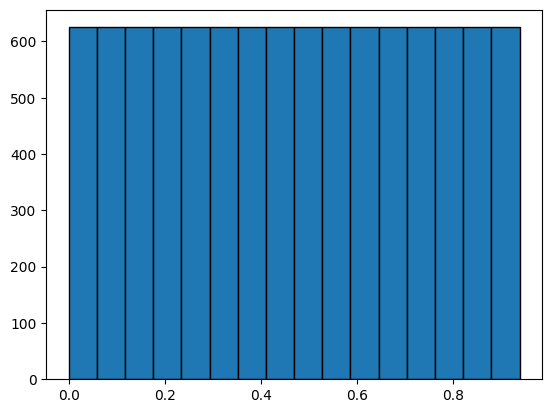

In [136]:
#plot.plot(Values)

plt.hist(Values, bins=16,edgecolor = "black")

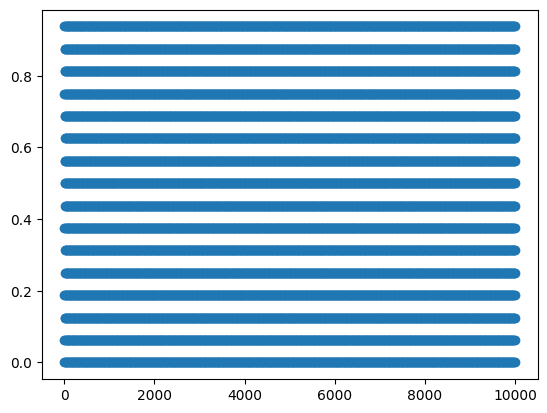

In [137]:
plt.scatter(np.arange(len(Values)),Values)

In [ ]:
data = Values
F = lambda x: x  # uniform fordeling 

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    n = len(data_sorted)
    p = (np.arange(n)+1)/n   # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    D_Fixed = (np.sqrt(n)+0.12+0.11/np.sqrt(n))*D
    return D_Fixed

In [139]:
def chisq_test(counts,N):
    T = 0
    n_classes = len(counts)
    for i in range(n_classes):
        n_expected = N*1/n_classes
        n_observed = counts[i]
        T += (n_observed-n_expected)**2 / n_expected

    p_val = 1-ss.chi2.cdf(T,df=n_classes-1)
    return p_val

In [140]:
a = [129, 5, 1103515245, 1664525]
c = [26461, 1, 12345, 1013904223]
M = [64499, 16, 2**31, 2**32]
N = [10_000, 10_000, 10_000, 10_000]
x0 = [30,30,30,30]

In [141]:
for i in range(4):
    array = LCG(a[i],c[i],M[i],N[0],x0[0])/M[i]
    print(smirnov(array,F))

0.8774949491928582
6.25756875
0.6678122896257045
1.6116257577814772


In [142]:
def run_test_1(x):
    m = np.median(x)
    n1 = np.sum(x > m)
    n2 = np.sum(x <= m)

    mu_T = 2 * n1*n2 / (n1+n2) + 1 # Mean, or Expected number of runs
    sig_T = np.sqrt(2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)**2 * (n1+n2-1))) # Variance

    s = (x > m) # Number of runs above the median

    T = 1 + np.sum(s[1:] != s[:-1]) # Compare adjacent elements to obtain T

    Z = (T - mu_T) / sig_T # Measure how far we are from what we expect
    p =  2*(1 - ss.norm.cdf(abs(Z)))
    return p    

In [143]:
smirnov(data,F)

np.float64(6.25756875)

# 2


In [144]:
np.random.seed(30)
data= np.random.uniform(low= 0, high=1,size=10_000)


In [145]:
run_test_1(data)

np.float64(0.0750613939575997)

In [146]:

data = LCG(a[0],c[0],M[0],N[0],x0[0])/M[0]
#print(smirnov(data,F))
print(run_test_1(data))

0.3897653356239932


# 3

In [147]:
P_CHISQ = []
T_Smirnov = []
P_Wald = []

F = lambda x: x  # uniform fordeling 
n = 10000 
for i in range(n):
    arr = LCG(a[0],c[0],M[0],N[0], x0=i)/M[0]
    counts, bin_edges = np.histogram(arr, bins=10)
    
    P_CHISQ.append(chisq_test(counts,N[0]))
    T_Smirnov.append(smirnov(arr,F))
    P_Wald.append(run_test_1(arr))

Critical_value = 1.358 # alpha = 0.05
T_smirnov = np.array(T_Smirnov)
T_smirnov_number_of_passed = np.size(T_smirnov[T_smirnov < Critical_value])
T_smirnov_not_passed = n - T_smirnov_number_of_passed

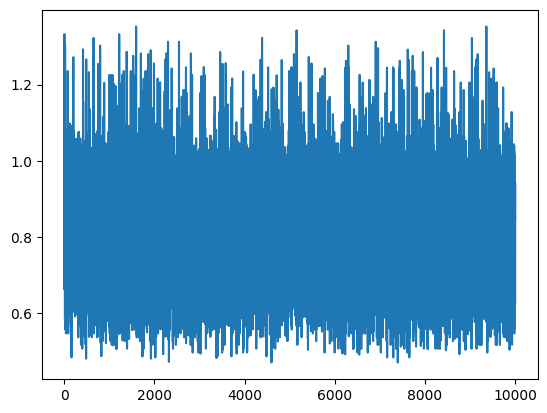

In [148]:
plt.plot(T_smirnov)

In [132]:
T_smirnov_not_passed, T_smirnov_number_of_passed

(0, 10000)

Text(0, 0.5, 'Counts')

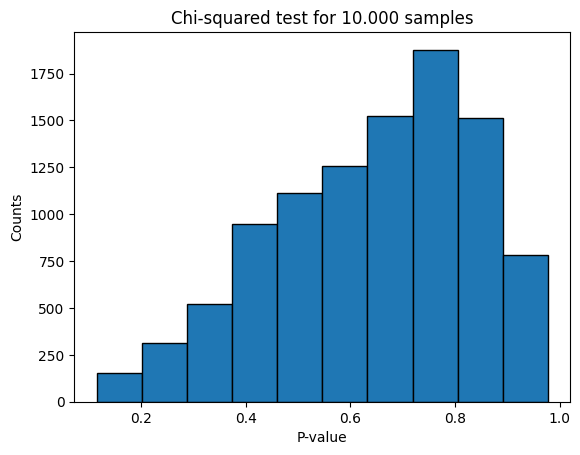

In [131]:
plt.hist(P_CHISQ, edgecolor="black")
plt.title("Chi-squared test for 10.000 samples")
plt.xlabel("P-value")
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

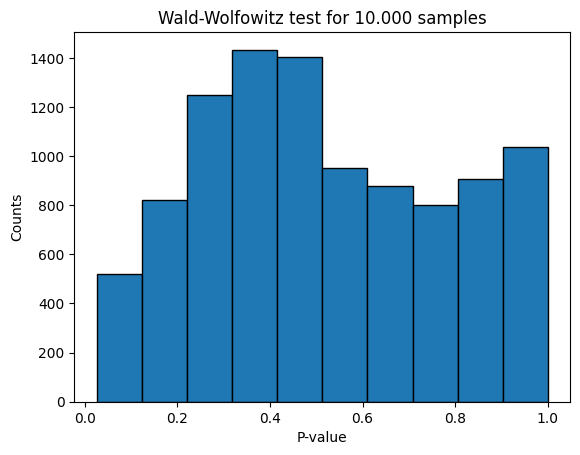

In [130]:
plt.hist(P_Wald, edgecolor="black")
plt.title("Wald-Wolfowitz test for 10.000 samples")
plt.xlabel("P-value")
plt.ylabel("Counts")